# PIPELINE STEPS : VALIDATED STEPS ONLY

### Important for auto reloading any changes in files in VS CODE withouting restarting kernel

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

project_root = os.path.abspath("../..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

### For auto correcting execution path for notebook

In [3]:
import os
print(os.getcwd())
import sys
import os

project_root = os.path.abspath("./..")

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

/home/arun/Desktop/AIProjects/rag-evaluation-framework/experiments
/home/arun/Desktop/AIProjects/rag-evaluation-framework


## Stage 1 : Imports

In [4]:
from raglens.parsers.docling_parser import (
    DoclingParser
)

from raglens.parsers.markdown_section_parser import (
    MarkdownSectionParser
)
from raglens.preprocessing.formula_cleaner import (
    FormulaCleaner
)
from raglens.parsers.level_inference import (
    LevelInference
)
from raglens.normalization.section_flattener import (
    SectionFlattener
)

/home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Stage : Corpus Collection

#### PDF Collection

In [5]:
from pathlib import Path

sources = []

PDF_DIR = (
    Path(project_root)
    / "data"
    / "documents"
)

for pdf in PDF_DIR.glob("*.pdf"):

    sources.append(
        str(pdf)
    )

sources.extend(
    [
        "https://arxiv.org/pdf/1706.03762.pdf",
        "https://arxiv.org/pdf/1810.04805.pdf",
        "https://arxiv.org/pdf/2005.14165.pdf",
        "https://arxiv.org/pdf/2004.04906.pdf",
        "https://arxiv.org/pdf/2007.00808.pdf",
        "https://arxiv.org/pdf/2010.00904.pdf",
        "https://arxiv.org/pdf/2005.11401.pdf",
        "https://arxiv.org/pdf/2312.10997.pdf",
        "https://arxiv.org/pdf/2402.19473.pdf",
        "https://arxiv.org/pdf/2410.12837.pdf",
        "https://arxiv.org/pdf/2104.08663.pdf",
        "https://arxiv.org/pdf/2212.09741.pdf",
        "https://arxiv.org/pdf/2506.18027.pdf",
        "https://arxiv.org/pdf/2410.15944.pdf"
           
    ]
)

print(
    f"{len(sources)} sources found"
)

for source in sources:

    print(source)

27 sources found
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/lbdl.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Transformer_Architecture_Guide.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Agentic_AI_and_Orchestration_Brief.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/vectors_and_embeddings.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Generative_AI_Fundamentals.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Vectorless_RAG_Technical_Report.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/knowledge_graphs_agentic_ai.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/LangGraph_Comprehensive_Guide.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Guardrails_and_Evals_in_Agentic_AI.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/L

## Stage 2: Parsing source documents using Docling

In [16]:
docling=DoclingParser()
all_markdowns = []
for source in sources:
    print("=" * 80)
    print("Processing:")
    print(source)
    try:
        markdown = docling.parse(
            source
        )
        all_markdowns.append(
            markdown
        )
        print(
            f"Success | Length: {len(markdown)}"
        )
    except Exception as e:
        print(
            f"Failed: {e}"
        )

Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/lbdl.pdf


[INFO] 2026-06-14 02:10:23,698 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-14 02:10:23,704 [RapidOCR] download_file.py:60: File exists and is valid: /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-14 02:10:23,705 [RapidOCR] main.py:57: Using /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-14 02:10:23,781 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-14 02:10:23,783 [RapidOCR] download_file.py:60: File exists and is valid: /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-14 02:10:23,783 [RapidOCR] main.py:57: Using /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile

Success | Length: 158466
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Transformer_Architecture_Guide.pdf
Success | Length: 7181
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Agentic_AI_and_Orchestration_Brief.pdf
Success | Length: 8699
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/vectors_and_embeddings.pdf
Success | Length: 7324
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Generative_AI_Fundamentals.pdf
Success | Length: 6076
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Vectorless_RAG_Technical_Report.pdf
Success | Length: 8833
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/knowledge_graphs_agentic_ai.pdf
Success | Length: 8988
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/LangGraph_Comprehensive_Guide.pdf
Success | Length: 6091
Proces

[WARNING] 2026-06-14 02:13:07,450 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!
[WARNING] 2026-06-14 02:13:07,660 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!
[WARNING] 2026-06-14 02:13:07,784 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!


Success | Length: 136085
Processing:
https://arxiv.org/pdf/2410.12837.pdf
Success | Length: 52418
Processing:
https://arxiv.org/pdf/2104.08663.pdf
Success | Length: 115027
Processing:
https://arxiv.org/pdf/2212.09741.pdf
Success | Length: 90594
Processing:
https://arxiv.org/pdf/2506.18027.pdf
Success | Length: 49785
Processing:
https://arxiv.org/pdf/2410.15944.pdf
Success | Length: 70700


In [17]:
print(
    "Sources:",
    len(sources)
)

print(
    "Markdown Documents:",
    len(all_markdowns)
)

Sources: 27
Markdown Documents: 27


## Storage : Caching parsed documents for future retrieval

In [6]:
from raglens.cache import (
    save_parsed_documents
)

save_parsed_documents(
    all_markdowns
)

NameError: name 'all_markdowns' is not defined

## Fetch Cache : Cached parsed documents : cache layer

In [7]:
from raglens.cache import (
    parsed_documents_exist,
    load_parsed_documents
)
if parsed_documents_exist():
    parsed_documents = (
        load_parsed_documents()
    )
else:
    print(
        "No cached parsed documents found"
    )

Loaded -> data/cache/parsed_documents.pkl


In [8]:
all_markdowns=parsed_documents

In [9]:
print(
    "Markdown Documents:",
    len(all_markdowns)
)

Markdown Documents: 27


## Stage 3: Process (string :text in markdown format) obtained from Docling parsing for LATEX errors

In [10]:
cleaner = FormulaCleaner()

all_cleaned_markdowns = []

for markdown in all_markdowns:

    cleaned = cleaner.process_markdown(
        markdown
    )

    all_cleaned_markdowns.append(
        cleaned
    )

print(
    f"Processed {len(all_cleaned_markdowns)} documents"
)

Processed 27 documents


## Stage 4: Creating a document(markdown parser needs 2 inputs a string(markdown text) and A Document(random)

In [11]:
from raglens.models.document import Document
documents = []
for idx, source in enumerate(sources):
    title = (
        source.split("/")[-1]
        .replace(".pdf", "")
    )
    doc = Document(
        doc_id=f"doc_{idx}",
        title=title,
        source_type="pdf",
        source_path=source
    )
    documents.append(
        doc
    )
print(
    f"{len(documents)} documents created"
)

27 documents created


### This parser parses the string to remove any markdown format in the string

In [12]:
parser = MarkdownSectionParser()
parsed_documents = []
for document, markdown in zip(
    documents,
    all_cleaned_markdowns
):
    parsed_doc = parser.parse(
        markdown,
        document
    )
    parsed_documents.append(
        parsed_doc
    )
print(
    f"{len(parsed_documents)} documents parsed"
)

27 documents parsed


## Stage 5: Level Inferencing constructs levels in a documents based on a set of rules

In [13]:
inferencer = LevelInference()
inferred_documents = []
for document in parsed_documents:

    inferred_doc = inferencer.infer(
        document
    )
    inferred_documents.append(
        inferred_doc
    )
print(
    f"{len(inferred_documents)} documents inferred"
)

27 documents inferred


## Stage 6: Hierarchy builder builds the hierarchy based on the levels we created

In [14]:
from raglens.parsers.hierarchy_builder import (
    HierarchyBuilder
)
builder = HierarchyBuilder()
hierarchy_documents = []

for document in inferred_documents:
    hierarchy_doc = builder.build(
        document
    )
    hierarchy_documents.append(
        hierarchy_doc
    )
    
print(
    f"{len(hierarchy_documents)} documents processed"
)

27 documents processed


## Stage 7: Convert heirarchical document tree into flat list while preserving hierarchy information in the path(metadata)

In [15]:
flattener = SectionFlattener()
all_flattened_sections = []

for document in hierarchy_documents:
    flattened = flattener.flatten(
        document
    )
    all_flattened_sections.extend(
        flattened
    )

print(
    "Flattened sections:",
    len(all_flattened_sections)
)

Flattened sections: 672


## Stage 8: Section Chunker -Section aware + Structure (Tables/Formula) Aware Chunking

In [15]:
import importlib

import raglens.chunking.section_chunker

importlib.reload(
    raglens.chunking.section_chunker
)

<module 'raglens.chunking.section_chunker' from '/home/arun/Desktop/AIProjects/rag-evaluation-framework/raglens/chunking/section_chunker.py'>

In [16]:
from raglens.chunking.section_chunker import (
    SectionChunker
)
chunker = SectionChunker()
all_chunks = []

for document in hierarchy_documents:
    flattened_sections = flattener.flatten(
        document
    )
    chunks = chunker.chunk(
        document=document,
        sections=flattened_sections
    )
    all_chunks.extend(
        chunks
    )

print(
    f"{len(all_chunks)} chunks created"
)

1777 chunks created


In [17]:
print(
    "Documents:",
    len(hierarchy_documents)
)
print(
    "Chunks:",
    len(all_chunks)
)
print(
    "Avg Chunks Per Document:",
    len(all_chunks) / len(hierarchy_documents)
)

Documents: 27
Chunks: 1777
Avg Chunks Per Document: 65.81481481481481


### Cell for Validating Chunks before embedding creation

In [18]:
import importlib

import raglens.validation.chunk_auditor

importlib.reload(
    raglens.validation.chunk_auditor
)

from raglens.validation.chunk_auditor import (
    ChunkAuditor
)

print("ChunkAuditor reloaded successfully.")

ChunkAuditor reloaded successfully.


In [18]:
from raglens.validation.chunk_auditor import(ChunkAuditor)
auditor = ChunkAuditor()
auditor.audit(
    all_chunks
)

CHUNK AUDIT REPORT

Chunk Types
----------------------------------------
parent_section: 637
table_fragment: 187
section_fragment: 953

Size Statistics
----------------------------------------
Min: 3
Max: 52144
Average: 1657.31
Chunks >5000 chars: 70
Non-parent chunks >5000 chars: 0

Largest Chunks
----------------------------------------
Type: parent_section
Size: 9982
Section: Contents
Type: parent_section
Size: 6136
Section: 4.6 Normalizing layers
Type: parent_section
Size: 6852
Section: Synthesis
Type: parent_section
Size: 5469
Section: 8.2 Quantization
Type: parent_section
Size: 11323
Section: Bibliography
Type: parent_section
Size: 5990
Section: Index
Type: parent_section
Size: 10915
Section: 6.2 Model Variations
Type: parent_section
Size: 7109
Section: References
Type: parent_section
Size: 6972
Section: 4.2 SQuAD v1.1
Type: parent_section
Size: 11361
Section: References
Type: parent_section
Size: 13208
Section: 1 Introduction
Type: parent_section
Size: 7390
Section: 2 Approach
T

In [19]:
too_large = [
    c
    for c in all_chunks
    if (
        c.chunk_type != "parent_section"
        and len(c.content) > 5000
    )
]

print(
    "Violations:",
    len(too_large)
)

for c in too_large:

    print(
        len(c.content),
        c.chunk_type,
        c.section_title
    )

Violations: 0


In [20]:
import importlib

import raglens.embedding.embedding_generator

importlib.reload(
    raglens.embedding.embedding_generator
)

<module 'raglens.embedding.ollama_embedding_generator' from '/home/arun/Desktop/AIProjects/rag-evaluation-framework/raglens/embedding/ollama_embedding_generator.py'>

## Embedding generator starts here 

In [21]:
from raglens.embedding import EmbeddingGenerator, get_embedding_provider

In [22]:
print(len(all_chunks))

1777


In [23]:
embedding_chunks = [
    chunk
    for chunk in all_chunks
    if chunk.chunk_type != "parent_section"
]

print(
    len(embedding_chunks)
)

1140


In [24]:
embedding_provider = get_embedding_provider("ollama")
embedding_generator = EmbeddingGenerator(embedding_provider)
chunk_embeddings = (
    embedding_generator.generate(
        embedding_chunks
    )
)
print(
    len(chunk_embeddings)
)

Processed 50/1140 chunks
Processed 100/1140 chunks
Processed 150/1140 chunks
Processed 200/1140 chunks
Processed 250/1140 chunks
Processed 300/1140 chunks
Processed 350/1140 chunks
Processed 400/1140 chunks
Processed 450/1140 chunks
Processed 500/1140 chunks
Processed 550/1140 chunks
Processed 600/1140 chunks
Processed 650/1140 chunks
Processed 700/1140 chunks
Processed 750/1140 chunks
Processed 800/1140 chunks
Processed 850/1140 chunks
Processed 900/1140 chunks
Processed 950/1140 chunks
Processed 1000/1140 chunks
Processed 1050/1140 chunks
Processed 1100/1140 chunks
Processed 1140/1140 chunks
1140


### Emeddings Storage phase

In [25]:
from raglens.vectorstore import (
    ChromaStore
)
store = ChromaStore()
store.reset()
store.add_embeddings(
    chunk_embeddings
)

print(
    "Stored:",
    store.count()
)

Stored: 1140


# Retrieval Phase : Complete variety of retrieval techniques implemented

#### validation to check what is returned

## Reloading new modules

In [26]:
def clear_project_modules(
    prefix="raglens"
):
    import sys

    for module in list(sys.modules):
        if module.startswith(prefix):
            del sys.modules[module]

    print(
        f"Cleared modules under {prefix}"
    )

# usage clear_project_modules("raglens.retrieval")

## Dense Retriever :Initialization

In [27]:

from raglens.retrieval.dense import (
    DenseRetriever
)

dense_retriever = DenseRetriever(
    embedding_model=embedding_provider,
    vector_store=store
)

## BM25 Retriever : Initialization 

In [28]:
from raglens.retrieval.bm25 import (
    BM25Retriever
)

bm25_retriever = BM25Retriever(
    embedding_chunks
)

print("BM25 initialized")

BM25 initialized


## Hybrid Retriever : Initialization

In [29]:
from raglens.retrieval.hybrid import (
    HybridRetriever
)

hybrid_retriever = (
    HybridRetriever(
        dense_retriever=dense_retriever,
        bm25_retriever=bm25_retriever
    )
)

print(
    "Hybrid initialized"
)

Hybrid initialized


## Hierarchical Retrieval :Initialization

In [30]:
from raglens.retrieval.hierarchical import (
    HierarchicalRetriever
)
hierarchical_retriever = (
    HierarchicalRetriever(
        hybrid_retriever=hybrid_retriever,
        all_chunks=all_chunks
    )
)


## Neighbor Retrieval : Initialization

In [32]:
from raglens.retrieval.neighbor import (
    NeighborRetriever
)
flat_neighbor_retriever = (
    NeighborRetriever(
        hybrid_retriever=hybrid_retriever,
        embedding_chunks=embedding_chunks
    )
)

# Question Generation Phase

In [33]:
from collections import Counter

counter = Counter(
    chunk.chunk_type
    for chunk in all_chunks
)

print(counter)

Counter({'section_fragment': 953, 'parent_section': 637, 'table_fragment': 187})


In [34]:
from raglens.config import (
    DEFAULT_CONFIG
)

usable_chunks = []

for chunk in all_chunks:

    if chunk.chunk_type != "section_fragment":
        continue

    if (
        DEFAULT_CONFIG.exclude_reference_sections
        and
        DEFAULT_CONFIG.is_bad_section(
            chunk.section_title
        )
    ):
        continue

    if len(
        chunk.content.strip()
    ) < 200:
        continue

    usable_chunks.append(
        chunk
    )

print(
    "Usable Chunks:",
    len(usable_chunks)
)

Usable Chunks: 627


### Question Generator Initialization

In [35]:
from raglens.question_generation import (
    QuestionGenerator
)
question_generator = (
    QuestionGenerator()
)

In [36]:
from raglens.question_generation import (
    QuestionDatasetBuilder
)
builder = (
    QuestionDatasetBuilder()
)
builder.build(
    usable_chunks
)

[1/627] SKIPPING doc_0_Stochastic Gradient Descent_32
[2/627] SKIPPING doc_0_Stochastic Gradient Descent_33
[3/627] SKIPPING doc_0_Stochastic Gradient Descent_34
[4/627] SKIPPING doc_0_3.6 Training protocols_40
[5/627] SKIPPING doc_0_3.6 Training protocols_41
[6/627] SKIPPING doc_0_3.6 Training protocols_42
[7/627] SKIPPING doc_0_3.7 The benefits of scale_45
[8/627] SKIPPING doc_0_3.7 The benefits of scale_46
[9/627] SKIPPING doc_0_3.7 The benefits of scale_47
[10/627] SKIPPING doc_0_3.7 The benefits of scale_48
[11/627] SKIPPING doc_0_Convolutional layers_54
[12/627] SKIPPING doc_0_Convolutional layers_55
[13/627] SKIPPING doc_0_Convolutional layers_56
[14/627] SKIPPING doc_0_Convolutional layers_57
[15/627] SKIPPING doc_0_Convolutional layers_58
[16/627] SKIPPING doc_0_ters unchanged._60
[17/627] SKIPPING doc_0_ters unchanged._61
[18/627] SKIPPING doc_0_ters unchanged._62
[19/627] SKIPPING doc_0_ters unchanged._63
[20/627] SKIPPING doc_0_4.6 Normalizing layers_68
[21/627] SKIPPING do

### Loading Questions

In [40]:
from raglens.question_generation import (
    QuestionDatasetLoader
)
loader = QuestionDatasetLoader()
samples = loader.load()
print(len(samples))

622


In [46]:
from raglens.retrieval.neighbor import (
    NeighborHierarchicalRetriever
)

neighbor_retriever = (
    NeighborHierarchicalRetriever(
        hierarchical_retriever=
            hierarchical_retriever,
        all_chunks=all_chunks,
        window=1
    )
)

---
## Full Retrieval Benchmark

### Note on BM25 scores
BM25 returns raw Okapi scores (0 → ∞). Dense returns cosine similarity in [0, 1].  
**For all rank-based metrics (Hit@K, MRR, NDCG) only the rank order matters — not the absolute score — so the incompatible scales do NOT affect evaluation numbers.**  
The Hybrid already normalises both to [0, 1] before fusion (min-max per retriever).

| Retriever | Strategy |
|-----------|----------|
| BM25 | Lexical keyword matching |
| Dense | Semantic vector similarity (Ollama) |
| Hybrid | Weighted fusion: Dense + BM25, 50/50 |
| Hierarchical | Hybrid → promote best child to parent section context |
| Hier+Neighbor | Hierarchical → expand ±1 adjacent fragment window |

In [47]:
clear_project_modules("raglens.evaluation")

from raglens.evaluation import run_benchmark

K_VALUES = [1, 3, 5, 10]
flat_bench, hier_bench, nbr_bench = run_benchmark(
    samples,
    bm25_retriever,
    dense_retriever,
    hybrid_retriever,
    hierarchical_retriever,
    neighbor_retriever,
    k_values=K_VALUES,
)

Cleared modules under raglens.evaluation
Running full benchmark across all retrievers and K values...
Total samples: 622

  BM25 @ k=1 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.756  mrr=0.756  ndcg=0.756  lat=2.2ms
  BM25 @ k=3 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.870  mrr=0.805  ndcg=0.822  lat=2.2ms
  BM25 @ k=5 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.902  mrr=0.813  ndcg=0.835  lat=2.1ms
  BM25 @ k=10 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.929  mrr=0.816  ndcg=0.844  lat=2.1ms
  Dense @ k=1 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.519  mrr=0.519  ndcg=0.519  lat=15.3ms
  Dense @ k=3 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
50

In [48]:
from raglens.evaluation import build_comparison_table

build_comparison_table(flat_bench, hier_bench, nbr_bench, K_VALUES)

/home/arun/Desktop/AIProjects/rag-evaluation-framework/raglens/evaluation/benchmark_visualizer.py:240: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(lat_names, rotation=15, ha="right", fontsize=9)


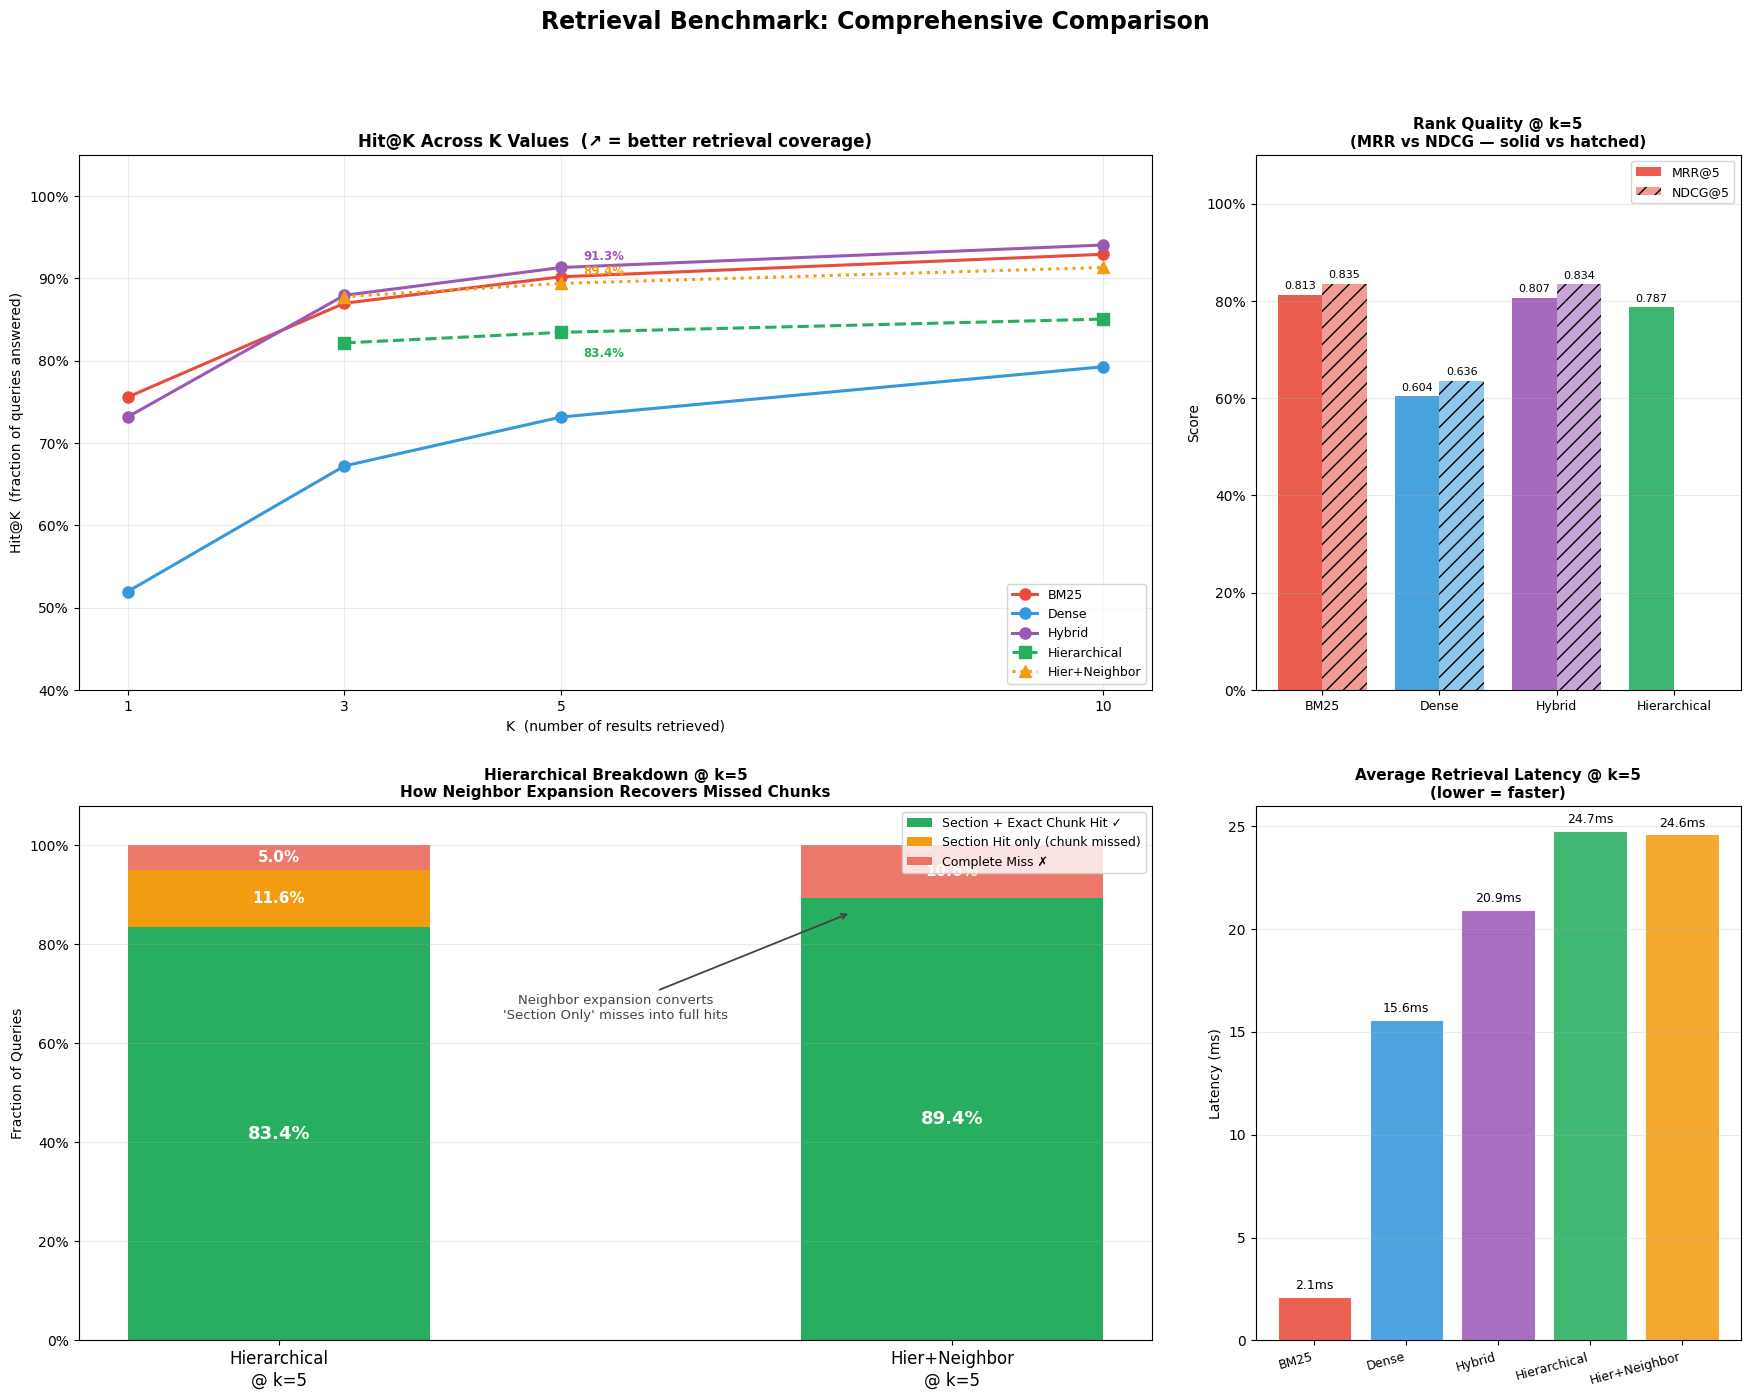

Chart saved to experiments/data/benchmark_chart.png


In [49]:
from raglens.evaluation import plot_benchmark_chart

plot_benchmark_chart(flat_bench, hier_bench, nbr_bench, K_VALUES)

In [263]:
import os, sys, types, logging, warnings
from dotenv import load_dotenv
load_dotenv()

os.environ["RAGAS_DO_NOT_TRACK"] = "true"

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
)
logging.getLogger("ragas").setLevel(logging.WARNING)
logging.getLogger("tenacity").setLevel(logging.WARNING)

# Patch missing langchain_community.chat_models.vertexai module
_fake_vtx = types.ModuleType("langchain_community.chat_models.vertexai")
class _ChatVertexAI: pass
_fake_vtx.ChatVertexAI = _ChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = _fake_vtx

from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.run_config import RunConfig
from ragas.metrics._faithfulness import Faithfulness
from ragas.metrics._factual_correctness import FactualCorrectness
from ragas.metrics._context_precision import ContextPrecision
from ragas.metrics._context_recall import ContextRecall
from ragas import aevaluate
from ragas.dataset_schema import EvaluationDataset
from raglens.ragas import RagasDatasetLoader

async_openai = AsyncOpenAI()
judge_llm = llm_factory(
    model="gpt-4o-mini",
    provider="openai",
    client=async_openai,
    temperature=0,
    max_tokens=1024,
)

print(f"judge_llm : {type(judge_llm).__name__}")
print(f"model     : gpt-4o-mini")
print(f"is_async  : {judge_llm.is_async}")
print("Telemetry : DISABLED (RAGAS_DO_NOT_TRACK=true)")


judge_llm : InstructorLLM
model     : gpt-4o-mini
is_async  : True
Telemetry : DISABLED (RAGAS_DO_NOT_TRACK=true)


In [264]:
import asyncio
from ragas.metrics._context_precision import QAC, Verification
from ragas.metrics.base import ensembler

class FastContextPrecision(ContextPrecision):
    """Evaluates all k contexts in parallel (asyncio.gather) instead of
    the default sequential loop. Drops job time from k×latency to 1×latency."""

    async def _ascore(self, row, callbacks):
        user_input, retrieved_contexts, reference = self._get_row_attributes(row)

        async def score_one(context):
            verdicts = await self.context_precision_prompt.generate_multiple(
                data=QAC(question=user_input, context=context, answer=reference),
                llm=self.llm,
                callbacks=callbacks,
            )
            return [v.model_dump() for v in verdicts]

        all_responses = await asyncio.gather(
            *[score_one(ctx) for ctx in retrieved_contexts]
        )

        answers = []
        for response in all_responses:
            agg = ensembler.from_discrete([response], "verdict")
            answers.append(Verification(**agg[0]))

        return self._calculate_average_precision(answers)

print("FastContextPrecision ready — parallel gather over k contexts")


FastContextPrecision ready — parallel gather over k contexts


In [265]:
METRICS = [
    Faithfulness(),
    FactualCorrectness(),
    FastContextPrecision(),
    ContextRecall(),
]

print("Metrics ready:", [m.name for m in METRICS])


Metrics ready: ['faithfulness', 'factual_correctness', 'context_precision', 'context_recall']


In [266]:
dataset = RagasDatasetLoader().load()
print(f'Loaded {len(dataset.samples)} samples')

s = dataset.samples[0]
print(f'user_input  : {s.user_input[:80]}')
print(f'contexts    : {len(s.retrieved_contexts)} chunks')
print(f'response len: {len(s.response)}')
print(f'reference len: {len(s.reference)}')


Loaded 1222 samples
user_input  : What assumption allows a partial sum of the gradient to be an unbiased estimator
contexts    : 5 chunks
response len: 62
reference len: 86


In [267]:
import random
from collections import defaultdict

random.seed(42)
EVAL_N = 150

# Group sample indices by source document (doc_0, doc_1, ... doc_26)
doc_buckets = defaultdict(list)
for i, s in enumerate(samples):
    doc_num = s.metadata["chunk_id"].split("_", 2)[1]
    doc_buckets[doc_num].append(i)

# Proportional stratified sampling — each doc contributes ~EVAL_N/622 fraction
eval_indices = []
for doc_num, indices in sorted(doc_buckets.items(), key=lambda x: int(x[0])):
    n = max(1, round(len(indices) / len(samples) * EVAL_N))
    eval_indices.extend(random.sample(indices, min(n, len(indices))))

# Adjust to exactly EVAL_N
if len(eval_indices) > EVAL_N:
    eval_indices = random.sample(eval_indices, EVAL_N)
elif len(eval_indices) < EVAL_N:
    pool = [i for i in range(len(samples)) if i not in set(eval_indices)]
    eval_indices.extend(random.sample(pool, EVAL_N - len(eval_indices)))

eval_indices    = sorted(eval_indices)
eval_samples    = [samples[i] for i in eval_indices]
target_chunk_ids = {s.metadata["chunk_id"] for s in eval_samples}

print(f"Stratified sample  : {len(eval_indices)} / {len(samples)}")
print(f"Source documents   : {len(doc_buckets)}")
print(f"Avg per document   : {len(eval_indices) / len(doc_buckets):.1f}")


Stratified sample  : 150 / 622
Source documents   : 15
Avg per document   : 10.0


In [268]:
# All 5 retrievers available in this notebook session
EVAL_RETRIEVERS = {
    "bm25":         bm25_retriever,
    "dense":        dense_retriever,
    "hybrid":       hybrid_retriever,
    "hierarchical": hierarchical_retriever,
    "neighbor":     neighbor_retriever,
}
print("Registered retrievers:", list(EVAL_RETRIEVERS.keys()))


Registered retrievers: ['bm25', 'dense', 'hybrid', 'hierarchical', 'neighbor']


In [269]:
from raglens.ragas import EvaluationDatasetBuilder, AnswerGenerator, AnswerDatasetBuilder

_eval_builder   = EvaluationDatasetBuilder()
_answer_gen     = AnswerGenerator()
_answer_builder = AnswerDatasetBuilder(_answer_gen)

print(f"Generating answers for {len(eval_samples)} eval samples x {len(EVAL_RETRIEVERS)} retrievers")
print("Already-cached (chunk_id, retriever) pairs are skipped.\n")

for _name, _retriever in EVAL_RETRIEVERS.items():
    print(f"--- {_name} ---")
    _ragas_ds = _eval_builder.build(
        eval_samples,
        _retriever,
        _name,
        k=5,
    )
    _answer_builder.build(_ragas_ds)
    print()

print("Answer generation complete.")


Generating answers for 150 eval samples x 5 retrievers
Already-cached (chunk_id, retriever) pairs are skipped.

--- bm25 ---
50/150
100/150
150/150

--- dense ---


2026-06-17 05:02:25,973 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:25,993 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,011 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,027 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,042 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,059 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,077 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,093 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,108 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:26,123 [htt

50/150


2026-06-17 05:02:27,077 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,094 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,109 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,130 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,155 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,173 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,193 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,212 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,229 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:27,246 [htt

100/150


...

50/150


2026-06-17 05:02:36,733 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,757 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,780 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,804 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,827 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,856 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,879 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,901 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,925 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:36,951 [htt

100/150


2026-06-17 05:02:37,953 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:37,980 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,005 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,030 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,053 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,079 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,106 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,131 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,154 [httpx] INFO: HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"
2026-06-17 05:02:38,177 [htt

150/150

Answer generation complete.


In [ ]:
run_config = RunConfig(
    timeout=300,
    max_retries=2,
    max_workers=2,
)

# Smoke test: 3 samples, all metrics
# Confirmed working config — smoke test completed in ~22 min at 3AM off-peak
_smoke = EvaluationDataset(samples=dataset.samples[:3])
print("Smoke test: 3 samples x 4 metrics  (max_workers=2, timeout=300) ...\n")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    _result = await aevaluate(
        dataset=_smoke,
        metrics=METRICS,
        llm=judge_llm,
        run_config=run_config,
        show_progress=True,
    )

_df = _result.to_pandas()
_score_cols = [c for c in _df.columns if c in [
    "faithfulness", "factual_correctness(mode=f1)", "context_precision", "context_recall"
]]
print("\nSmoke test scores:")
print(_df[_score_cols].to_string())
print("\nMeans:")
print(_df[_score_cols].mean().round(4).to_string())
print("\nrun_config ready for full evaluation loop.")


In [272]:
run_config = RunConfig(
    timeout=1200,
    max_retries=3,
    max_workers=2,
)

In [ ]:
import json
import warnings
import pandas as pd
from pathlib import Path
from ragas.dataset_schema import EvaluationDataset, SingleTurnSample

SCORES_PATH  = Path("data/cache/ragas_scores.jsonl")
ANSWER_CACHE = Path("data/cache/generated_answers/generated_answers.jsonl")
BATCH_SIZE   = 10   # save every 10 samples (~70 min); balances safety vs throughput

SCORE_COLS = [
    "faithfulness",
    "factual_correctness(mode=f1)",
    "context_precision",
    "context_recall",
]
DISPLAY_NAMES = {
    "faithfulness":                 "Faithfulness",
    "factual_correctness(mode=f1)": "Factual Correctness",
    "context_precision":            "Context Precision",
    "context_recall":               "Context Recall",
}

def _load_done_keys(path):
    if not path.exists():
        return set()
    done = set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            done.add((r["retriever"], r["chunk_id"]))
    return done

def _load_pending_samples(retriever_name, chunk_ids, done_keys):
    pending = sorted(
        cid for cid in chunk_ids
        if (retriever_name, cid) not in done_keys
    )
    chunk_to_rec = {}
    with open(ANSWER_CACHE, "r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            if (rec.get("status") == "success"
                    and rec.get("retriever") == retriever_name
                    and rec.get("chunk_id") in set(pending)):
                chunk_to_rec[rec["chunk_id"]] = rec

    ragas_samples, ordered_ids = [], []
    for cid in pending:
        if cid not in chunk_to_rec:
            continue
        r = chunk_to_rec[cid]
        ragas_samples.append(SingleTurnSample(
            user_input=str(r["question"]),
            retrieved_contexts=r["contexts"],
            response=str(r["generated_answer"]),
            reference=str(r["reference_answer"]),
        ))
        ordered_ids.append(cid)
    return ragas_samples, ordered_ids

def _append_scores(path, retriever_name, chunk_ids, batch_df):
    """Append one batch of results to JSONL immediately after batch completes."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        for i, chunk_id in enumerate(chunk_ids):
            row = batch_df.iloc[i]
            rec = {"retriever": retriever_name, "chunk_id": chunk_id}
            for col in SCORE_COLS:
                val = row[col] if col in batch_df.columns else None
                rec[col] = float(val) if (val is not None and pd.notna(val)) else None
            f.write(json.dumps(rec) + "\n")

done_keys   = _load_done_keys(SCORES_PATH)
all_results = {}

for retriever_name in EVAL_RETRIEVERS:
    already_done = sum(1 for (r, c) in done_keys
                       if r == retriever_name and c in target_chunk_ids)
    pending_samples, pending_ids = _load_pending_samples(
        retriever_name, target_chunk_ids, done_keys
    )

    print(f"\n{'='*60}")
    print(f"Retriever : {retriever_name}")
    print(f"Cached    : {already_done} / {len(target_chunk_ids)} | Remaining: {len(pending_samples)}")

    for batch_start in range(0, len(pending_samples), BATCH_SIZE):
        batch_end     = min(batch_start + BATCH_SIZE, len(pending_samples))
        batch_samples = pending_samples[batch_start:batch_end]
        batch_ids     = pending_ids[batch_start:batch_end]

        print(f"  [{batch_start+1:03d}:{batch_end:03d}] evaluating {len(batch_samples)} samples ...", flush=True)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", DeprecationWarning)
                batch_result = await aevaluate(
                    dataset=EvaluationDataset(samples=batch_samples),
                    metrics=METRICS,
                    llm=judge_llm,
                    run_config=run_config,
                    show_progress=True,
                )
            batch_df = batch_result.to_pandas()
            _append_scores(SCORES_PATH, retriever_name, batch_ids, batch_df)
            done_keys.update((retriever_name, cid) for cid in batch_ids)
            means = {col: round(batch_df[col].mean(), 4)
                     for col in SCORE_COLS if col in batch_df.columns}
            print(f"    saved {len(batch_ids)} samples | means: {means}")
        except Exception as e:
            print(f"    BATCH FAILED ({type(e).__name__}: {e}) — skipping, will retry on next run")

    # Aggregate from cache for this retriever
    scores = {col: [] for col in SCORE_COLS}
    with open(SCORES_PATH, "r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            if rec["retriever"] == retriever_name and rec["chunk_id"] in target_chunk_ids:
                for col in SCORE_COLS:
                    val = rec.get(col)
                    if val is not None:
                        scores[col].append(val)

    all_results[retriever_name] = {
        col: round(sum(v) / len(v), 4) if v else None
        for col, v in scores.items()
    }
    print(f"  Mean → {all_results[retriever_name]}")

# ── Comparison table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame(all_results).T
comparison.columns = [DISPLAY_NAMES.get(c, c) for c in comparison.columns]
comparison.index.name = "Retriever"

comparison.to_csv("data/cache/ragas_results.csv")
print(f"\nSaved → data/cache/ragas_results.csv")
print(f"\n{'='*60}")
print("RAGAS SCORES — 150-sample stratified, 5 retrievers")
print(f"{'='*60}")
print(comparison.round(4).to_string())

(
    comparison.style
    .format("{:.4f}")
    .highlight_max(axis=0, props="font-weight:bold; color:green")
    .highlight_min(axis=0, props="color:red")
    .set_caption("RAGAS Scores by Retriever (green = best, red = worst per metric)")i
)



Retriever : bm25
Cached    : 0 / 150 | Remaining: 150
  [001:010] evaluating 10 samples ...


 ... (more hidden) ...2026-06-17 05:12:43,264 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 05:13:23,285 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 05:13:23,286 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 05:14:45,451 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 05:15:25,483 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 05:15:25,484 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 05:16:47,584 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 05:16:47,585 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.

    saved 10 samples | means: {'faithfulness': np.float64(0.8375), 'factual_correctness(mode=f1)': np.float64(0.77), 'context_precision': np.float64(0.9), 'context_recall': np.float64(1.0)}
  [011:020] evaluating 10 samples ...


 ... (more hidden) ...2026-06-17 06:34:40,408 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 06:35:20,432 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 06:35:20,433 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 06:36:46,574 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 06:36:46,575 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 06:38:06,617 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 06:38:48,337 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 06:39:28,372 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 0

    saved 10 samples | means: {'faithfulness': np.float64(0.7281), 'factual_correctness(mode=f1)': np.float64(0.504), 'context_precision': np.float64(0.7417), 'context_recall': np.float64(0.8)}
  [021:030] evaluating 10 samples ...


...

 ... (more hidden) ...2026-06-17 13:22:32,563 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 13:23:12,606 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 13:23:12,607 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 13:24:37,499 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 13:25:17,534 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 13:25:17,535 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 13:26:39,751 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 13:26:39,753 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 1

    saved 10 samples | means: {'faithfulness': np.float64(1.0), 'factual_correctness(mode=f1)': np.float64(0.753), 'context_precision': np.float64(0.895), 'context_recall': np.float64(0.9)}
  [071:080] evaluating 10 samples ...


 ... (more hidden) ...2026-06-17 14:44:38,278 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 14:45:18,316 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 14:45:18,317 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 14:46:41,974 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 14:47:22,008 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 14:47:22,009 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 14:48:44,444 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 14:49:24,462 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/cha

    saved 10 samples | means: {'faithfulness': np.float64(0.8833), 'factual_correctness(mode=f1)': np.float64(0.753), 'context_precision': np.float64(0.7893), 'context_recall': np.float64(1.0)}
  [081:090] evaluating 10 samples ...


 ... (more hidden) ...2026-06-17 16:06:54,495 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 16:07:34,536 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 16:07:34,537 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 16:08:57,001 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 16:09:37,040 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 16:09:37,041 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
 ... (more hidden) ...2026-06-17 16:10:58,833 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 16:10:58,834 [httpx] INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-17 1

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics    = list(comparison.columns)
retrievers = list(comparison.index)
x          = np.arange(len(retrievers))
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle(
    "RAGAS Scores by Retriever — 150 Stratified Samples",
    fontsize=14, fontweight="bold"
)

for ax, metric, color in zip(axes, metrics, colors):
    vals = comparison[metric].values.astype(float)
    bars = ax.bar(x, vals, color=color, alpha=0.82, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(retrievers, rotation=35, ha="right", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.axhline(vals.mean(), color="gray", linestyle="--", linewidth=0.9, label="mean")
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

plt.tight_layout()
plt.savefig("data/cache/ragas_benchmark_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → data/cache/ragas_benchmark_chart.png")
